In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

from math import gcd, lcm
from tqdm import tqdm
from matplotlib.patches import Circle

from fractions import Fraction

In [ ]:
def return_degree(idx_lst):

    for idx, val in enumerate(idx_lst):
        if val != 0:
            return len(idx_lst) - idx

    return 0

def create_basic_starscapes_3_case(coeff_range_1, coeff_range_2, coeff_range_3, scale):
    roots_lst = []
    size_lst = []
    color_lst = []
    polynomial_definition_lst = []
    for x in tqdm(range(coeff_range_1[0], coeff_range_1[1] + 1)):
        for y in range(coeff_range_2[0], coeff_range_2[1] + 1):
            for z in range(coeff_range_3[0], coeff_range_3[1] + 1):
                lst_of_vals = [x, z, z, 4, x, y]
                if (gcd(x, y, z) == 1) and (np.sum(np.abs(lst_of_vals))):
                    lst_of_found_roots_spec = list(np.roots(lst_of_vals)) #x, z, y, z, x, y
                    roots_lst += lst_of_found_roots_spec

                    polynomial_definition_lst += [(x, y, z)]*len(lst_of_found_roots_spec)

                    deg = return_degree(lst_of_vals)

                    new_vals = lst_of_vals[len(lst_of_vals) - deg]

                    size_lst += [scale/np.abs((2*new_vals)) for _ in range(len(lst_of_found_roots_spec))]

                    color_lst += [deg]*len(lst_of_found_roots_spec)

    return roots_lst, size_lst, color_lst, polynomial_definition_lst

def return_colors(deg):

    if deg == 0:
        return "orange"
    
    if deg == 1:
        return "crimson"
    
    if deg == 2:
        return "gold"
    
    if deg == 3:
        return "lightseagreen"
    
    if deg == 4:
        return "blue"

    if deg == 5:
        return "red"
    
    if deg == 6:
        return "orange"
    
    if deg == 7:
        return "orange"

def draw_starscapes(roots_lst, size_lst, color_lst, xlims, ylims, scales, cmap = "turbo"):
    fig, ax = plt.subplots()
    ax.axis("off")
    ax.set(xlim = xlims, ylim = ylims)

    fig.set_facecolor("black")

    pbar = tqdm(total = len(roots_lst))

    for pt, sz, cl in zip(roots_lst, size_lst, color_lst):
        pbar.update(1)
        if (pt.real > xlims[0]) and (pt.real < xlims[1]) and (pt.imag > ylims[0]) and (pt.imag < ylims[1]):
            ax.add_artist(Circle(xy = (pt.real, pt.imag*np.cosh(scales*sz)),
                        radius = pt.imag*np.sinh(scales*sz), color = return_colors(cl))
                        )

    pbar.close()

    return fig

def invariante_measure(out, step_size, x_min = None, x_max = None):
    min_val_out = x_min if x_min is not None else np.min(out)
    max_val_out = x_max if x_min is not None else np.max(out)
    z_min = np.arange(min_val_out, max_val_out, step_size)
    z_max = np.arange(min_val_out + step_size, max_val_out + step_size, step_size)

    ranges_to_test = [(a,b) for (a, b) in zip(z_min, z_max)]

    count_for_range = []

    for rng in ranges_to_test:
        values_in_range = np.sum((out > rng[0]) & (out < rng[1]))
        count_for_range.append(values_in_range)

    return count_for_range, ranges_to_test


def draw_starscapes(roots_lst, size_lst, color_lst, xlims, ylims, scales, cmap = "turbo"):
    fig, ax = plt.subplots()
    ax.axis("off")
    ax.set(xlim = xlims, ylim = ylims)

    fig.set_facecolor("black")

    pbar = tqdm(total = len(roots_lst))

    for pt, sz, cl in zip(roots_lst, size_lst, color_lst):
        pbar.update(1)
        if (pt.real > xlims[0]) and (pt.real < xlims[1]) and (pt.imag > ylims[0]) and (pt.imag < ylims[1]):
            ax.add_artist(Circle(xy = (pt.real, pt.imag*np.cosh(scales*sz)),
                        radius = pt.imag*np.sinh(scales*sz), color = return_colors(cl),
                        zorder = 1/pt.imag*np.sinh(scales*sz)
                        ))

    pbar.close()

    return fig

In [63]:
n = 20
root_lst, size_lst, c_lst, poly_lst = create_basic_starscapes_3_case((-n, n), (-n, n), (-n, n), scale = .01)

  0%|          | 0/41 [00:00<?, ?it/s]

100%|██████████| 41/41 [00:08<00:00,  4.92it/s]


100%|██████████| 284102/284102 [00:11<00:00, 23996.66it/s]
/var/folders/vv/zk5gs3vd2jj5d_hz9mz28hr80000gn/T/ipykernel_17978/1497727709.py:1: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  draw_starscapes(root_lst, size_lst, c_lst, (-1, 1), (0, 1.75), .5).show()


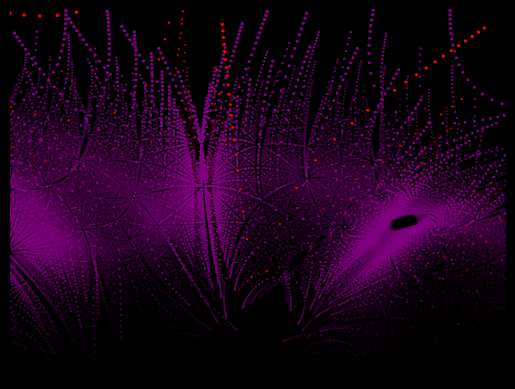

In [66]:
draw_starscapes(root_lst, size_lst, c_lst, (-1, 1), (0, 1.75), .5).show()